In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install tensorflow

  Using cached numpy-2.1.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.1.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.2
    Uninstalling numpy-1.25.2:
      Successfully uninstalled numpy-1.25.2

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install opendatasets --upgrade


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [4]:
pip install imgaug


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install numpy==1.25.2

  Using cached numpy-1.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 1.25.2 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.25.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [6]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [7]:
!pip install plotly


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import os
from os import listdir, makedirs, getcwd, remove
from os.path import isfile, join, abspath, exists, isdir, expanduser
import opendatasets as od

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import random
from pathlib import Path

import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.compat.v1 import Session, ConfigProto, set_random_seed
from tensorflow.python.client import device_lib

from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.layers import Conv2D, MaxPool2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K

import cv2

from skimage.io import imread
from skimage.transform import resize

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from PIL import Image
import imgaug as aug
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt
import matplotlib.image as mimg
%matplotlib inline
import seaborn as sns
import plotly.express as px


2025-04-30 04:08:28.897625: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745986108.916281    8220 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745986108.922062    8220 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745986108.936495    8220 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745986108.936515    8220 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745986108.936517    8220 computation_placer.cc:177] computation placer alr

In [9]:
od.download("https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia")

Skipping, found downloaded files in "./chest-xray-pneumonia" (use force=True to force download)


In [27]:
from pathlib import Path
import pandas as pd

# Define main dataset paths
base_dir = Path("chest-xray-pneumonia/chest_xray/chest_xray/")
train_dir = base_dir / "train"
val_dir = base_dir / "val"
test_dir = base_dir / "test"

# Define subfolders
train_normal_dir = train_dir / "NORMAL"
train_pneumonia_dir = train_dir / "PNEUMONIA"
valid_normal_dir = val_dir / "NORMAL"
valid_pneumonia_dir = val_dir / "PNEUMONIA"
test_normal_dir = test_dir / "NORMAL"
test_pneumonia_dir = test_dir / "PNEUMONIA"

# Create train_set
train_set = []
for img in train_normal_dir.glob("*.jpeg"):
    train_set.append((img, 0))
for img in train_pneumonia_dir.glob("*.jpeg"):
    train_set.append((img, 1))
train_set = pd.DataFrame(train_set, columns=["image", "label"]).sample(frac=1).reset_index(drop=True)

# Create valid_set
valid_set = []
for img in valid_normal_dir.glob("*.jpeg"):
    valid_set.append((img, 0))
for img in valid_pneumonia_dir.glob("*.jpeg"):
    valid_set.append((img, 1))
valid_set = pd.DataFrame(valid_set, columns=["image", "label"]).sample(frac=1).reset_index(drop=True)

# Create test_set
test_set = []
for img in test_normal_dir.glob("*.jpeg"):
    test_set.append((img, 0))
for img in test_pneumonia_dir.glob("*.jpeg"):
    test_set.append((img, 1))
test_set = pd.DataFrame(test_set, columns=["image", "label"]).sample(frac=1).reset_index(drop=True)

# Confirm creation
print(f"Train samples: {len(train_set)}")
print(f"Validation samples: {len(valid_set)}")
print(f"Test samples: {len(test_set)}")

Train samples: 5216
Validation samples: 16
Test samples: 624


In [28]:
# --- Existing code for CNN remains the same ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data generators for CNN
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# CNN Train Generator (grayscale)
train_generator_cnn = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=8,
    class_mode='categorical',
    color_mode='grayscale'
)

# CNN Validation Generator (grayscale)
val_generator_cnn = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=8,
    class_mode='categorical',
    shuffle=False,
    color_mode='grayscale'
)

# --- New: VGG Manual Data Loading from full train_set and test_set ---

from tensorflow.keras.utils import to_categorical

# Helper function to prepare VGG data (RGB images resized to 224x224)
def prepare_data_for_vgg(data_set, img_size=224):
    X = []
    y = []
    for _, row in data_set.iterrows():
        img_path = row['image']
        label = row['label']
        img = cv2.imread(str(img_path))  # read in RGB
        if img is None:
            continue  # skip unreadable images
        img = cv2.resize(img, (img_size, img_size))
        X.append(img)
        y.append(label)
    return np.array(X)/255.0, np.array(y)
# Prepare VGG training and testing data from full dataset
X_train_vgg, y_train_vgg = prepare_data_for_vgg(train_set)
X_test_vgg, y_test_vgg = prepare_data_for_vgg(test_set)

# One-hot encode the labels for categorical classification
y_train_vgg_cat = to_categorical(y_train_vgg, num_classes=2)
y_test_vgg_cat = to_categorical(y_test_vgg, num_classes=2)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [29]:
tf.__version__

'2.19.0'

In [30]:
import tensorflow as tf

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


I0000 00:00:1745986410.081074    8220 gpu_device.cc:2019] Created device /device:GPU:0 with 46746 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:25:00.0, compute capability: 8.6
I0000 00:00:1745986410.084162    8220 gpu_device.cc:2019] Created device /device:GPU:1 with 46746 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


In [31]:
os.listdir(train_dir)

['.DS_Store', 'NORMAL', 'PNEUMONIA']

In [32]:
train_normal_dir = train_dir /"NORMAL/"
train_pneumonia_dir = train_dir /"PNEUMONIA/"

In [33]:
os.listdir(val_dir)

['.DS_Store', 'NORMAL', 'PNEUMONIA']

In [34]:
os.listdir(test_dir)

['.DS_Store', 'NORMAL', 'PNEUMONIA']

In [35]:
test_normal_dir = test_dir /"NORMAL"
test_pneumonia_dir = test_dir /"PNEUMONIA"

In [36]:
train_normal= train_normal_dir.glob("*.jpeg")
train_pneumonia=train_pneumonia_dir.glob("*.jpeg")
train_set=[]

In [37]:
for img in train_normal:
  train_set.append((img, 0))
for img in train_pneumonia:
  train_set.append((img, 1))

In [38]:
print(train_set[:15])

[(PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/IM-0117-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/IM-0119-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/IM-0122-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/IM-0125-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/IM-0127-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/IM-0128-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/IM-0129-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/IM-0131-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/IM-0133-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/I

In [39]:
train_set=pd.DataFrame(train_set, columns=["image", "label"], index=None)

In [40]:
train_set.head()

,image,label
0,chest-xray-pneumonia/chest_xray/chest_xray/tra...,0
1,chest-xray-pneumonia/chest_xray/chest_xray/tra...,0
2,chest-xray-pneumonia/chest_xray/chest_xray/tra...,0
3,chest-xray-pneumonia/chest_xray/chest_xray/tra...,0
4,chest-xray-pneumonia/chest_xray/chest_xray/tra...,0


In [41]:
train_set=train_set.sample(frac=1)
train_set=train_set.reset_index(drop=True)
train_set.head()

,image,label
0,chest-xray-pneumonia/chest_xray/chest_xray/tra...,1
1,chest-xray-pneumonia/chest_xray/chest_xray/tra...,1
2,chest-xray-pneumonia/chest_xray/chest_xray/tra...,1
3,chest-xray-pneumonia/chest_xray/chest_xray/tra...,1
4,chest-xray-pneumonia/chest_xray/chest_xray/tra...,1


In [42]:
valid_normal= valid_normal_dir.glob("*.jpeg")
valid_pneumonia=valid_pneumonia_dir.glob("*.jpeg")
valid_set=[]

In [43]:
for img in valid_normal:
  valid_set.append((img, 0))
for img in valid_pneumonia:
  valid_set.append((img, 1))

In [44]:
print(valid_set[:15])

[(PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL/NORMAL2-IM-1427-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL/NORMAL2-IM-1430-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL/NORMAL2-IM-1431-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL/NORMAL2-IM-1437-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL/NORMAL2-IM-1438-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL/NORMAL2-IM-1440-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL/NORMAL2-IM-1442-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg'), 1), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg'),

In [45]:
valid_set=pd.DataFrame(valid_set, columns=["image", "label"], index=None)
valid_set.head()

,image,label
0,chest-xray-pneumonia/chest_xray/chest_xray/val...,0
1,chest-xray-pneumonia/chest_xray/chest_xray/val...,0
2,chest-xray-pneumonia/chest_xray/chest_xray/val...,0
3,chest-xray-pneumonia/chest_xray/chest_xray/val...,0
4,chest-xray-pneumonia/chest_xray/chest_xray/val...,0


In [46]:
valid_set=valid_set.sample(frac=1)
valid_set=valid_set.reset_index(drop=True)
valid_set.head()

,image,label
0,chest-xray-pneumonia/chest_xray/chest_xray/val...,0
1,chest-xray-pneumonia/chest_xray/chest_xray/val...,1
2,chest-xray-pneumonia/chest_xray/chest_xray/val...,0
3,chest-xray-pneumonia/chest_xray/chest_xray/val...,1
4,chest-xray-pneumonia/chest_xray/chest_xray/val...,1


In [47]:
test_normal= test_normal_dir.glob("*.jpeg") #to take the normal images from test set
test_pneumonia=test_pneumonia_dir.glob("*.jpeg") #to take the pneumonia images from the test set
test_set=[]

In [48]:
for img in test_normal: #to add every image of normals in test set to the list
  test_set.append((img, 0)) #we add 0 with normal images as label
for img in test_pneumonia:#to add every image of pneumonias in test set to the list
  test_set.append((img, 1)) #we add 1 with pneumonia images as label

In [49]:
print(test_set[:15])

[(PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM-0001-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM-0003-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM-0005-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM-0006-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM-0007-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM-0009-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM-0010-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM-0011-0001-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM-0011-0001-0002.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM-0011-0001.jpeg'), 0), (PosixPath('chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL/IM

In [50]:
test_set=pd.DataFrame(test_set, columns=["image", "label"], index=None)#to create a dataframe from the list, so that we can use dataframe features
test_set.head()

,image,label
0,chest-xray-pneumonia/chest_xray/chest_xray/tes...,0
1,chest-xray-pneumonia/chest_xray/chest_xray/tes...,0
2,chest-xray-pneumonia/chest_xray/chest_xray/tes...,0
3,chest-xray-pneumonia/chest_xray/chest_xray/tes...,0
4,chest-xray-pneumonia/chest_xray/chest_xray/tes...,0


In [51]:
test_set=test_set.sample(frac=1) #to shuffle all the rows in dataframe so that we can see normal and pneumonia in random
test_set=test_set.reset_index(drop=True) #to set the indexes as if first time
test_set.head()

,image,label
0,chest-xray-pneumonia/chest_xray/chest_xray/tes...,1
1,chest-xray-pneumonia/chest_xray/chest_xray/tes...,1
2,chest-xray-pneumonia/chest_xray/chest_xray/tes...,1
3,chest-xray-pneumonia/chest_xray/chest_xray/tes...,1
4,chest-xray-pneumonia/chest_xray/chest_xray/tes...,1


In [52]:
train_normal_count= train_set.loc[train_set["label"]==0]["image"].count()
print("Total number of normal images:", train_normal_count)

Total number of normal images: 1341


In [53]:
train_pneumonia_count= train_set.loc[train_set["label"]==1]["image"].count()
print("Total number of pneumonia images:", train_pneumonia_count)

Total number of pneumonia images: 3875


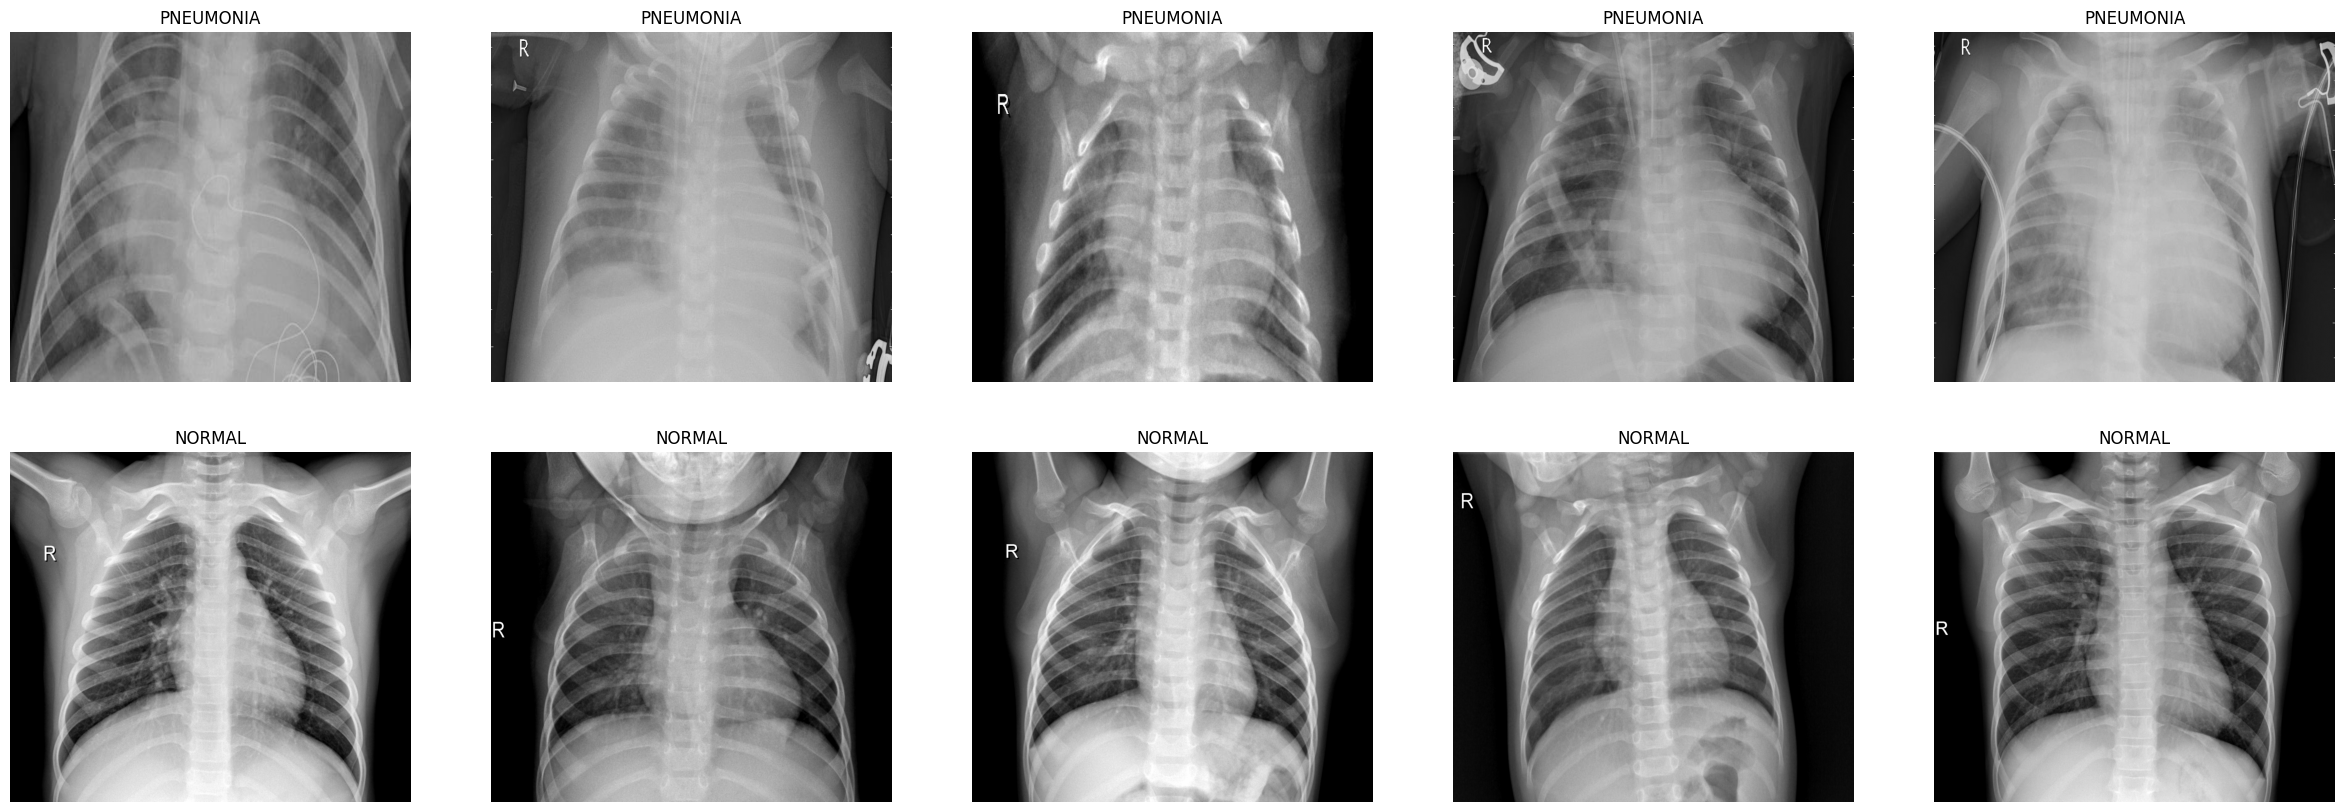

In [54]:
pneumonia_samples = (train_set[train_set["label"] == 1]["image"].iloc[:5]).tolist()
normal_samples = (train_set[train_set["label"] == 0]["image"].iloc[:5]).tolist()

# Concate the data in a single list and del the above two list
samples = pneumonia_samples + normal_samples
del pneumonia_samples, normal_samples

# Plot the data
f, ax = plt.subplots(2,5, figsize = (30,10))
for i in range(10):
    img = imread(samples[i])
    ax[i//5, i % 5].imshow(img, cmap='gray')
    if i < 5:
        ax[i//5, i % 5].set_title("PNEUMONIA")
    else:
        ax[i//5, i % 5].set_title("NORMAL")
    ax[i//5, i % 5].axis('off')
    ax[i//5, i % 5].set_aspect('auto')
plt.show()

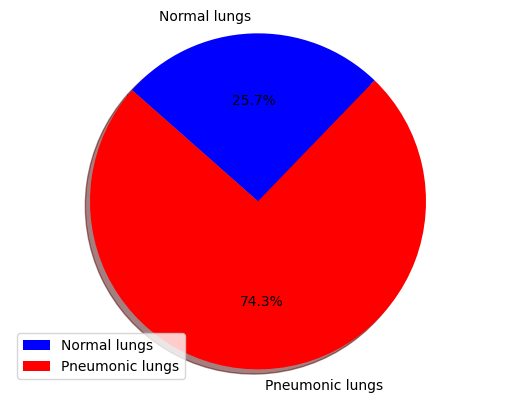

In [55]:
fig1,ax1= plt.subplots()
sizes=[train_normal_count, train_pneumonia_count]
ax1.pie(sizes, startangle=46 ,labels=["Normal lungs","Pneumonic lungs"], autopct="%1.1f%%", shadow=True, colors=["b","r"])
ax1.axis("equal")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Case Distribution')

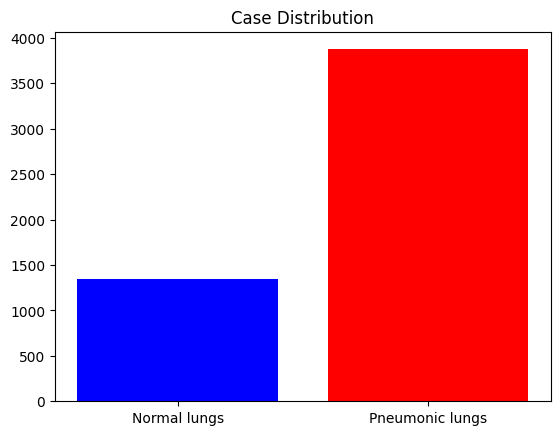

In [56]:
fig2, ax2=plt.subplots()
ax2.bar(height=sizes, x=["Normal lungs", "Pneumonic lungs"], color=["blue", "red"])
plt.title("Case Distribution")

In [57]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 150


def get_training_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                # Reshaping images to preferred size
                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                # Ensure resized_arr is the correct shape before appending
                if resized_arr.shape == (img_size, img_size):
                    data.append([resized_arr, class_num])
                else:
                    print(f"Skipping image {img} due to incorrect shape: {resized_arr.shape}")
            except Exception as e:
                print(e)
    return np.array(data, dtype=object)

In [58]:
train = get_training_data(train_dir)
test = get_training_data(test_dir)
val = get_training_data(val_dir)

OpenCV(4.11.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'

OpenCV(4.11.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'

OpenCV(4.11.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'

OpenCV(4.11.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'



In [59]:
X_train, X_val, X_test = ([], ) * 3
y_train, y_val, y_test = ([], ) * 3

for feature, label in train:
    X_train.append(feature)
    y_train.append(label)

for feature, label in val:
    X_val.append(feature)
    y_val.append(label)

for feature, label in test:
    X_test.append(feature)
    y_test.append(label)


In [60]:
X_train = np.array(X_train) /255
X_val = np.array(X_val) / 255
X_test = np.array(X_test) / 255

In [61]:
X_train = X_train.reshape (-1, img_size, img_size, 1)
y_train = np.array(y_train)

X_val = X_val.reshape(-1, img_size, img_size, 1)
y_val = np.array(y_val)

X_test = X_test.reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

In [62]:
image_generator = ImageDataGenerator(
  featurewise_center = False, # set input mean to 0 over the dataset
  samplewise_center = False, # set each sample mean to 0
  featurewise_std_normalization = False, #divide inputs by std of the dataset
  samplewise_std_normalization = False, # divide each input by its std
  zca_whitening=False,  # apply ZCA whitening
  rotation_range =30, #randomly rotate images in the range
  zoom_range = 0.2, #randomly zoom image
  width_shift_range = 0.1, #randomly shift images horizontally
  height_shift_range = 0.1, #randomly shift images vertically
  horizontal_flip = True, #randomly flip images
  vertical_flip = False) #randomly flip images

image_generator.fit(X_train)

In [63]:
model = Sequential()
model.add(Conv2D(32 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu' , input_shape = (150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(128 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(256 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Flatten())
model.add(Dense(units = 128 , activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 1 , activation = 'sigmoid'))
model.compile(optimizer = "rmsprop" , loss = 'binary_crossentropy' , metrics = ['accuracy'])
model.summary()

/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1745986438.388298    8220 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46746 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:25:00.0, compute capability: 8.6
I0000 00:00:1745986438.391338    8220 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46746 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [64]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=2, verbose=1, factor=0.3, min_lr=0.000001)

In [78]:
history = model.fit(image_generator.flow(X_train, y_train, batch_size=32), epochs=10, validation_data=image_generator.flow(X_val, y_val), callbacks=[learning_rate_reduction])

Epoch 1/10


/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


183/183 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.9634 - loss: 0.0969 - val_accuracy: 0.9657 - val_loss: 0.1036 - learning_rate: 2.7000e-05
Epoch 2/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.9651 - loss: 0.0969 - val_accuracy: 0.9636 - val_loss: 0.1033 - learning_rate: 2.7000e-05
Epoch 3/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9618 - loss: 0.1085
Epoch 3: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.
183/183 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.9618 - loss: 0.1085 - val_accuracy: 0.9643 - val_loss: 0.1047 - learning_rate: 2.7000e-05
Epoch 4/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.9627 - loss: 0.1049 - val_accuracy: 0.9647 - val_loss: 0.1047 - learning_rate: 8.1000e-06
Epoch 5/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.9675 - loss: 0.0966 - val_accuracy: 0.9664 - val_loss: 0.0998 - learning_rate: 8.1000e-06
Epoch 6/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.9

In [79]:
print("Loss of the model is - " , model.evaluate(X_test,y_test)[0])
print("Accuracy of the model is - " , model.evaluate(X_test,y_test)[1]*100 , "%")

183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9092 - loss: 0.2313
Loss of the model is -  0.18209493160247803
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9092 - loss: 0.2313
Accuracy of the model is -  92.91325211524963 %


ValueError: x and y must have same first dimension, but have shapes (15,) and (10,)

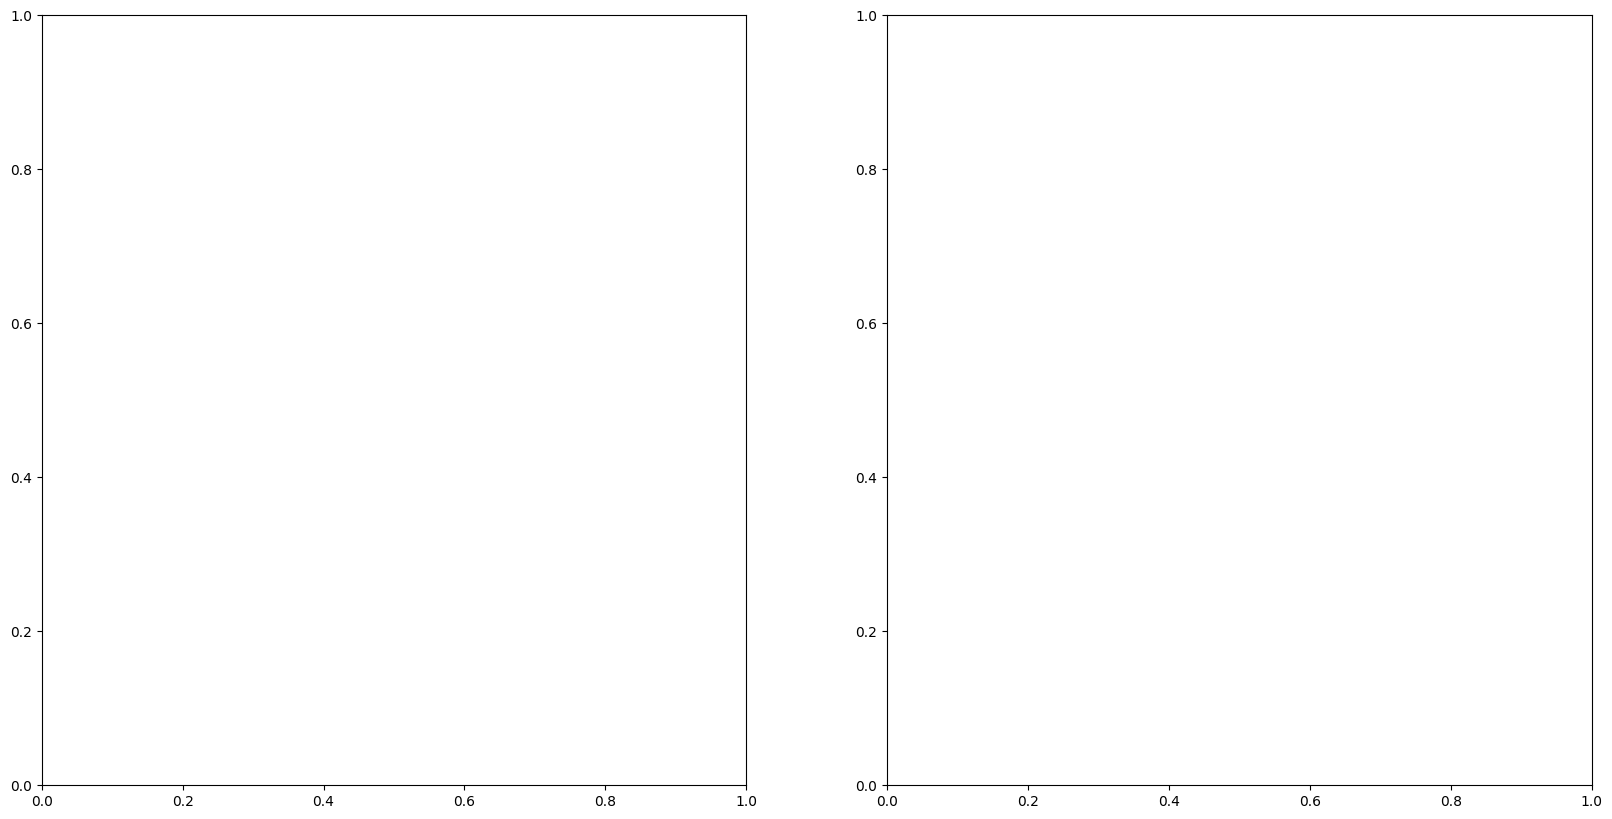

In [80]:
epochs = [i for i in range(15)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
fig.set_size_inches(20,10)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'ro-' , label = 'Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'r-o' , label = 'Validation Loss')
ax[1].set_title('Testing Accuracy & Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Training & Validation Loss")
plt.show()

In [81]:
predictions = (model.predict(X_test) > 0.5).astype("int32")
predictions = predictions.reshape(1, -1)[0]
predictions[:15]

183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], dtype=int32)

In [82]:
print(classification_report(y_test, predictions, target_names = ['Pneumonia (Class 0)','Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.99      0.91      0.95      4273
   Normal (Class 1)       0.80      0.98      0.88      1583

           accuracy                           0.93      5856
          macro avg       0.90      0.94      0.92      5856
       weighted avg       0.94      0.93      0.93      5856



In [83]:
cm = confusion_matrix(y_test, predictions)
cm

array([[3891,  382],
       [  33, 1550]])

In [84]:
cm = pd.DataFrame(cm, index=['0', '1'], columns=['0', '1'])

<Axes: >

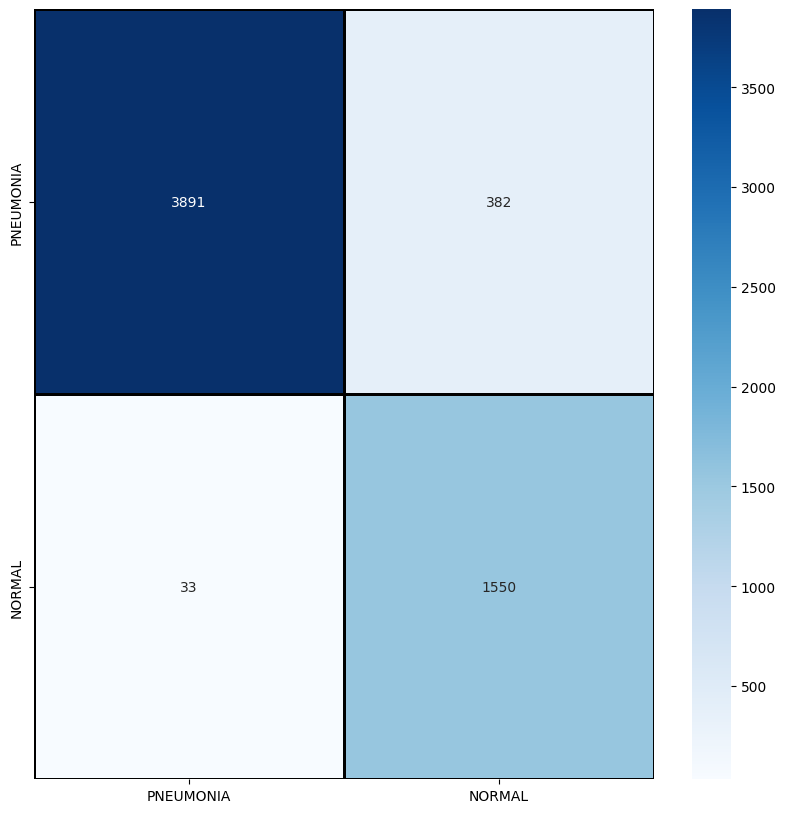

In [85]:
plt.figure(figsize = (10,10))
sns.heatmap(cm,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='',xticklabels = labels,yticklabels = labels)

In [86]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

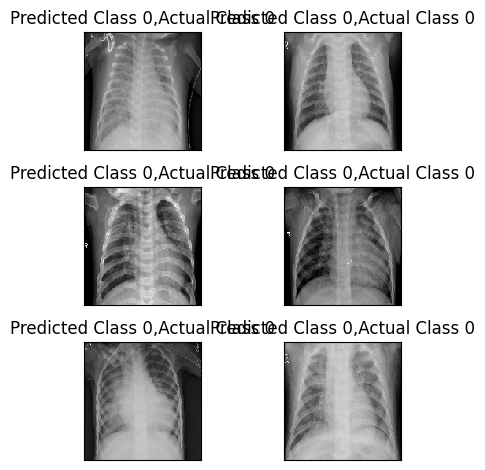

In [87]:
i = 0
for c in correct[:6]:
    plt.subplot(3, 2, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_test[c].reshape(150, 150), cmap="gray", interpolation='none')
    plt.title("Predicted Class {},Actual Class {}".format(
        predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1

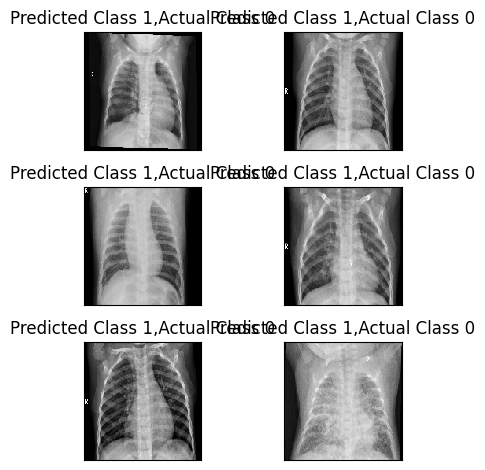

In [88]:
i = 0
for c in incorrect[:6]:
    plt.subplot(3, 2, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_test[c].reshape(150, 150), cmap="gray", interpolation='none')
    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1

# VGG Model Training and Evaluation

In [89]:
# VGG Model Training and Evaluation

from keras.applications import VGG16
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Load VGG16 base model without the top layer
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze last few layers of VGG16
for layer in vgg_base.layers[-4:]:  # e.g., unfreeze last 4 layers
    layer.trainable = True

# Add custom classification layers on top
x = Flatten()(vgg_base.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)  # 2 classes: Pneumonia, Normal

vgg_model = Model(inputs=vgg_base.input, outputs=output)

# Compile the model
vgg_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

vgg_model.summary()

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation generator for VGG
vgg_aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Optional: Not strictly required but useful if using feature-wise normalization
vgg_aug.fit(X_train_vgg)
vgg_history = vgg_model.fit(
    vgg_aug.flow(X_train_vgg, y_train_vgg_cat, batch_size=32),
    validation_data=(X_test_vgg, y_test_vgg_cat),
    epochs=20  # consider increasing to 20 or more
)

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,561,282 (105.14 MB)

 Trainable params: 27,561,282 (105.14 MB)

 Non-trainable params: 0 (0.00 B)

/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 254ms/step - accuracy: 0.8105 - loss: 0.4129 - val_accuracy: 0.8638 - val_loss: 0.3388
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 248ms/step - accuracy: 0.9205 - loss: 0.1918 - val_accuracy: 0.9006 - val_loss: 0.2549
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 243ms/step - accuracy: 0.9453 - loss: 0.1588 - val_accuracy: 0.9151 - val_loss: 0.2368
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 39s 240ms/step - accuracy: 0.9415 - loss: 0.1386 - val_accuracy: 0.9279 - val_loss: 0.2047
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 242ms/step - accuracy: 0.9550 - loss: 0.1232 - val_accuracy: 0.9199 - val_loss: 0.2197
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 244ms/step - accuracy: 0.9568 - loss: 0.1053 - val_accuracy: 0.9199 - val_loss: 0.2454
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 242ms/step - accuracy: 0.9625 - loss: 0.0962 - val_accuracy: 0.9119 - val_loss: 0.2575
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 39s 240ms/step - accuracy: 0.9642 - loss: 0

In [90]:
# Predict probabilities for each class (shape: [num_samples, 2])
y_pred_probs = vgg_model.predict(X_test_vgg)

# Convert predicted probabilities to class labels (0 or 1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded ground truth back to class labels
y_true = np.argmax(y_test_vgg_cat, axis=1)

# Print classification report (precision, recall, f1-score)
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {acc * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
Classification Report:
                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.99      0.72      0.83       234
   Normal (Class 1)       0.86      0.99      0.92       390

           accuracy                           0.89       624
          macro avg       0.92      0.86      0.88       624
       weighted avg       0.91      0.89      0.89       624

Test Accuracy: 89.26%


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Ensemble Accuracy: 81.25%
Ensemble Classification Report:
                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.70      0.88      0.78       234
   Normal (Class 1)       0.92      0.77      0.84       390

           accuracy                           0.81       624
          macro avg       0.81      0.83      0.81       624
       weighted avg       0.83      0.81      0.82       624



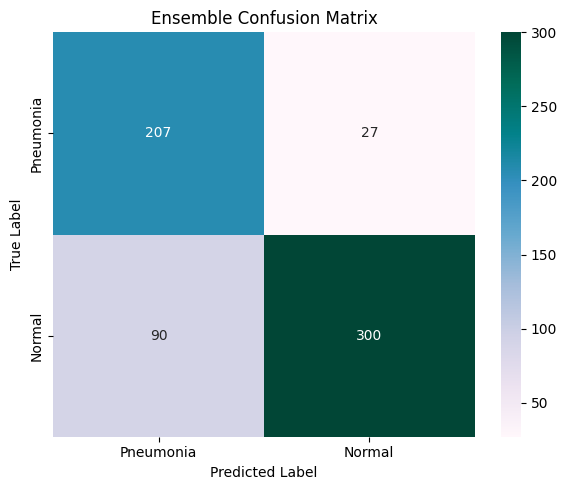

In [93]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Ensure test sample counts match ---
n_test_samples = len(y_test_vgg_cat)
X_test_cnn_aligned = X_test[:n_test_samples]

# --- Get predictions from both models ---
# CNN outputs sigmoid, shape (n, 1)
cnn_probs = model.predict(X_test_cnn_aligned)
cnn_probs_2class = np.hstack([1 - cnn_probs, cnn_probs])  # Convert to 2-class [P(0), P(1)]

# VGG outputs softmax, shape (n, 2)
vgg_probs = vgg_model.predict(X_test_vgg)

# --- Ensemble prediction: average both model probabilities ---
ensemble_probs = (cnn_probs_2class + vgg_probs) / 2.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# --- Ground truth labels ---
y_true = np.argmax(y_test_vgg_cat, axis=1)

# --- Accuracy ---
ensemble_acc = accuracy_score(y_true, ensemble_preds)
print(f"Ensemble Accuracy: {ensemble_acc * 100:.2f}%")

# --- Classification report ---
print("Ensemble Classification Report:")
print(classification_report(y_true, ensemble_preds, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, ensemble_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBuGn',
            xticklabels=['Pneumonia', 'Normal'],
            yticklabels=['Pneumonia', 'Normal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Ensemble Confusion Matrix')
plt.tight_layout()
plt.show()